Cell 1
-

In [1]:
import pandas as pd 

df = pd.read_csv("../data/processed_jobs.csv")

Cell 2
-

In [5]:
! pip install scikit-learn


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------------------------------------- 0/2 [threadpoolctl]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ----------

In [6]:

from sklearn.feature_extraction.text import TfidfVectorizer

Cell 3 
-

In [7]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_test = tfidf.fit_transform(
    df["combined_text"]
)

Cell 4
-

In [8]:
y = df["is_fake"]

Cell 5
-

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_test,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Cell 6
-

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Cell 7
-

In [11]:
pred_lr = lr.predict(X_test)

Cell 8
-

In [12]:
from sklearn.metrics import classification_report 

print(
    classification_report(
        y_test,
        pred_lr
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       306
           1       1.00      1.00      1.00       294

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



Cell 9
-

In [23]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(
    X_train,
    y_train
)

pred_nb = nb.predict(X_test)

print(
    classification_report(
        y_test,
        pred_nb
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       306
           1       1.00      1.00      1.00       294

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



Cell 10
-

In [24]:
from sklearn.ensemble import RandomForestClassifier 

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42

)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(X_test)

print(
    classification_report(
        y_test,
        pred_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       306
           1       1.00      1.00      1.00       294

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



Cell 11
-

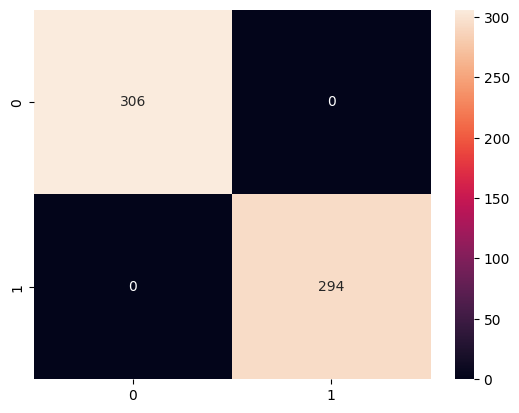

In [25]:
from sklearn.metrics import confusion_matrix 
import seaborn as sns 
import matplotlib.pyplot as plt 

cm = confusion_matrix(
    y_test,
    pred_lr
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()

Cell 12 
-

In [26]:
import pickle 

pickle.dump(
    tfidf,
    open("../models/tfidf.pkl","wb")

)

pickle.dump(
    lr,
    open("../models/model.pkl","wb")
)